# Kang PBMC — end-to-end pyvae sanity check

An end-to-end run of pyvae on the Kang 2018 PBMC dataset (control vs interferon-β stimulated).

The goal is to verify that pyvae's modern training loop (`train_ivae_modern`) and interpretation stack (`bayes_factor_da`, `integrated_gradients`, `predict_counterfactual`) recover the expected interferon-response biology.

Sections:
1. Setup and data loading
2. Reactome adjacency and covariate matrix
3. Model construction and training
4. UMAP of pathway activations
5. Differential module ranking (Bayes factor + Wilcoxon)
6. Gene-level attribution via Integrated Gradients
7. Conditioning and counterfactual prediction
8. Takeaways

## 1. Setup and data loading

In [14]:
from __future__ import annotations

from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import torch

import pyvae
from pyvae import (
    InformedVAE,
    bayes_factor_da,
    build_model_config,
    integrated_gradients,
    load_kang,
    set_all_seeds,
    sync_gexp_adj,
    train_ivae_modern,
)

# Deterministic runs
SEED = 42
set_all_seeds(SEED)

# Where to store the downloaded Kang data (git-ignored)
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

from importlib.metadata import version as _pkg_version

def _try_version(name):
    try:
        return _pkg_version(name)
    except Exception:
        return "(unavailable)"

print(f"pyvae version: {_try_version('pyvae')}")
print(f"torch version: {torch.__version__}")
print(f"scanpy version: {_try_version('scanpy')}")

pyvae version: 0.2.0
torch version: 2.12.1
scanpy version: 1.12.1


### Load the dataset

`load_kang` downloads the AnnData from figshare on first call, then caches it locally. It performs standard preprocessing:

- Normalizes to a fixed library size and applies `log1p`
- Selects highly variable genes (default: top 2000)
- Preserves raw counts in `adata.layers["counts"]` for the negative-binomial likelihood
- Maps the raw condition labels (`ctrl` / `stim`) to `control` / `stimulated`

In [24]:
# n_genes=5000 (not 2000 or larger). With 2000 HVGs, only 2/8 canonical ISGs
# survived the Reactome intersection. Widening to 5000 recovers 3 more
# (IFI6, IFIT1, IFIT2). MX1 and OAS1 remain absent from HVGs even at 8000 --
# they have real biological induction but their total dispersion doesn't
# rank them into the top-N via scanpy's HVG selection (likely because
# induction is monocyte-specific, diluting variance across the mixed
# population). Recovering them would require n_genes=None (all ~15k genes)
# which triples training time for marginal biological gain. IFI44 is absent
# from Reactome itself. Accepting 5/8 ISGs as the working input space.
adata = load_kang(data_folder=str(DATA_DIR), n_genes=5000)
adata

/Users/amiraynede/Thesis/pyvae/pyvae/datasets.py:68: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["label"] = adata.obs["label"].replace(


AnnData object with n_obs × n_vars = 24673 × 5000
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'condition', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters'
    var: 'name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

### Sanity check

Compare cell counts against Gundogdu et al. (2023), Table 1:

- Control: 1316 B, 2932 CD14+ Mono, 5560 CD4 T, 811 CD8 T, 258 DC, 520 FCGR3A+ Mono, 63 Megakaryocytes, 855 NK
- Stimulated: 1335 B, 2765 CD14+ Mono, 5678 CD4 T, 810 CD8 T, 271 DC, 569 FCGR3A+ Mono, 69 Megakaryocytes, 861 NK

Exact numbers will differ slightly (different HVG selection, filtering choices, scanpy versions), but the order of magnitude and overall structure should match.

In [26]:
print(f"AnnData shape: {adata.shape}   (cells x genes)")
print(f"n_cells: {adata.n_obs:,}")
print(f"n_genes (HVG): {adata.n_vars:,}")
print()
print("Available layers:", list(adata.layers.keys()))
print("Available obs columns:", list(adata.obs.columns))
print()

# Distribution by condition and cell type
xtab = pd.crosstab(adata.obs["cell_type"], adata.obs["condition"])
print("Cells by type x condition:")
print(xtab)
print()
print(f"Total control:    {(adata.obs['condition'] == 'control').sum():,}")
print(f"Total stimulated: {(adata.obs['condition'] == 'stimulated').sum():,}")

AnnData shape: (24673, 5000)   (cells x genes)
n_cells: 24,673
n_genes (HVG): 5,000

Available layers: ['counts']
Available obs columns: ['nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'condition', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters']

Cells by type x condition:
condition          control  stimulated
cell_type                             
CD4 T cells           5560        5678
CD14+ Monocytes       2932        2765
B cells               1316        1335
NK cells               855         861
CD8 T cells            811         810
FCGR3A+ Monocytes      520         569
Dendritic cells        258         271
Megakaryocytes          63          69

Total control:    12,315
Total stimulated: 12,358


## 2. Reactome adjacency and covariate matrix

Build the biological prior that constrains the encoder's first layer:

- **Adjacency matrix** — binary `(n_genes, n_pathways)` tensor from Reactome; entry `(i, j) = 1` iff gene `i` belongs to pathway `j`. This becomes the mask on `InformedLinear`.
- **Covariate matrix** — one-hot encoding of `condition` (control / stimulated). Feeds into the conditional-VAE machinery so we can do counterfactual prediction in Section 7 ("what would this control cell look like if stimulated?").

The adjacency is built via `build_model_config` (which reads Reactome from the pyvae resource bundle) and then aligned with the dataset's gene list via `sync_gexp_adj` so the two match row-for-row.

In [27]:
# Genes present in the current AnnData (after HVG selection)
gene_symbols = list(adata.var_names)
print(f"Genes in AnnData:      {len(gene_symbols):,}")

# Path to the Reactome GMT file (MSigDB c2.cp.reactome v7.5.1)
# See experiments/kang/README.md for how to obtain this file.
REACTOME_GMT = Path("resources") / "c2.cp.reactome.v7.5.1.symbols.gmt"
assert REACTOME_GMT.exists(), (
    f"GMT file not found at {REACTOME_GMT}. See experiments/kang/README.md."
)

# Build the Reactome-informed model config using the GMT.
# Note: build_model_config already intersects the adjacency with our gene
# list internally (via sync_gexp_adj), so the returned matrix is aligned.
config = build_model_config(
    genes=gene_symbols,
    model_kind="ivae_reactome",
    resources_dir=str(REACTOME_GMT),
)
adj_df = config.model_layer[0]

print(f"Reactome pathways (aligned): {adj_df.shape[1]:,}")
print(f"Genes aligned with Reactome: {adj_df.shape[0]:,}")
print(f"  (of {len(gene_symbols):,} HVGs; the rest are not in the GMT)")
print(f"\nAdjacency shape:             {adj_df.shape}")
print(f"Adjacency density:           {int(adj_df.values.sum()):,} ones out of {adj_df.size:,} entries "
      f"({100 * adj_df.values.mean():.2f}%)")

# Sanity check: verify canonical ISGs and interferon pathways survive
canonical_isgs = ["ISG15", "IFI6", "IFIT1", "IFIT2", "IFIT3", "MX1", "OAS1", "IFI44"]
present = [g for g in canonical_isgs if g in adj_df.index]
missing = [g for g in canonical_isgs if g not in adj_df.index]
print(f"\nCanonical ISGs present in aligned genes: {len(present)}/{len(canonical_isgs)}")
print(f"  Present: {present}")
if missing:
    print(f"  Missing: {missing}")

interferon_pathways = [p for p in adj_df.columns if "INTERFERON" in p.upper()]
print(f"\nReactome pathways matching 'interferon': {len(interferon_pathways)}")
for p in interferon_pathways[:10]:
    print(f"  {p}")

Genes in AnnData:      5,000
Reactome pathways (aligned): 1,615
Genes aligned with Reactome: 2,414
  (of 5,000 HVGs; the rest are not in the GMT)

Adjacency shape:             (2414, 1615)
Adjacency density:           19,160 ones out of 3,898,610 entries (0.49%)

Canonical ISGs present in aligned genes: 5/8
  Present: ['ISG15', 'IFI6', 'IFIT1', 'IFIT2', 'IFIT3']
  Missing: ['MX1', 'OAS1', 'IFI44']

Reactome pathways matching 'interferon': 4
  REACTOME_DDX58_IFIH1_MEDIATED_INDUCTION_OF_INTERFERON_ALPHA_BETA
  REACTOME_INTERFERON_ALPHA_BETA_SIGNALING
  REACTOME_INTERFERON_GAMMA_SIGNALING
  REACTOME_INTERFERON_SIGNALING


In [28]:
# Diagnostic: are the missing ISGs in the Reactome GMT at all, and in the AnnData?
missing_isgs = ["IFI6", "IFIT1", "IFIT2", "MX1", "OAS1", "IFI44"]

# Reload the full (pre-alignment) Reactome adjacency to see its gene coverage
from pyvae.bio import get_reactome_adj
full_reactome = get_reactome_adj(str(REACTOME_GMT))
print(f"Full Reactome GMT: {full_reactome.shape}")

# Check the AnnData (post-HVG, pre-Reactome intersection)
hvg_genes = set(adata.var_names)
reactome_genes = set(full_reactome.index)

print(f"\nMissing ISG status:")
print(f"{'gene':<8} {'in HVG?':<10} {'in Reactome?':<15}")
for g in missing_isgs:
    print(f"{g:<8} {str(g in hvg_genes):<10} {str(g in reactome_genes):<15}")

Full Reactome GMT: (10646, 1615)

Missing ISG status:
gene     in HVG?    in Reactome?   
IFI6     True       True           
IFIT1    True       True           
IFIT2    True       True           
MX1      False      True           
OAS1     False      True           
IFI44    True       False          


### Align genes between AnnData and adjacency

The Reactome adjacency covers ~12,000 human genes; our AnnData has 2,000 HVGs after HVG selection. `sync_gexp_adj` returns:

- A gene expression DataFrame restricted to the genes that appear in **both** sources
- An adjacency DataFrame with the same gene ordering

After this step, expression and adjacency share the same gene axis exactly.

In [30]:
# The adjacency from build_model_config is already aligned with our HVGs
# (build_model_config calls sync_gexp_adj internally). Convert to torch tensor.
adj_tensor = torch.tensor(adj_df.values, dtype=torch.float32)
print(f"adj_tensor: shape={tuple(adj_tensor.shape)}, dtype={adj_tensor.dtype}")

# Store aligned gene and pathway lists; we'll need them for interpretation
gene_names = list(adj_df.index)
pathway_names = list(adj_df.columns)
print(f"\nGenes:    {len(gene_names):,}   e.g. {gene_names[:3]}")
print(f"Pathways: {len(pathway_names):,}   e.g. {pathway_names[:3]}")

# Also subset the AnnData to the aligned genes so downstream cells work with
# the same gene axis as the model
adata_aligned = adata[:, gene_names].copy()
print(f"\nadata_aligned shape: {adata_aligned.shape}")

adj_tensor: shape=(2414, 1615), dtype=torch.float32

Genes:    2,414   e.g. ['AASDHPPT', 'AASS', 'ABCA2']
Pathways: 1,615   e.g. ['REACTOME_2_LTR_CIRCLE_FORMATION', 'REACTOME_ABACAVIR_METABOLISM', 'REACTOME_ABACAVIR_TRANSMEMBRANE_TRANSPORT']

adata_aligned shape: (24673, 2414)


### Build the covariate matrix

One-hot encoding of `condition` (control / stimulated), with cells indexed to match `X_aligned`. This will be threaded through the encoder heads and the NB decoder in Section 3.

In [31]:
# One-hot encode condition. pd.get_dummies preserves cell order.
cov_df = pd.get_dummies(adata_aligned.obs["condition"], prefix="condition").astype(np.float32)

print(f"Covariate matrix: {cov_df.shape}")
print(f"Columns: {list(cov_df.columns)}")
print()
print("Per-column sums (should match condition totals from Section 1):")
print(cov_df.sum())

n_cov = cov_df.shape[1]  # will feed InformedVAE(n_cov=...)
print(f"\nn_cov = {n_cov}")

Covariate matrix: (24673, 2)
Columns: ['condition_control', 'condition_stimulated']

Per-column sums (should match condition totals from Section 1):
condition_control       12315.0
condition_stimulated    12358.0
dtype: float32

n_cov = 2


## 3. Model construction and training

Build and train the `InformedVAE` on Kang. The pieces:

- **Model:** `InformedVAE` with the negative-binomial likelihood and the Reactome mask from Section 2. No covariate conditioning at training time — see the note at the end of the notebook for why.
- **Training loop:** `train_ivae_modern` — AdamW with cosine LR annealing, KL warmup, gradient clipping, patience-based early stopping.
- **Split:** 80/20 stratified by condition so both groups are proportionally represented in train and val.




In [42]:
from sklearn.model_selection import train_test_split

# --- Train/val split, stratified by condition ---
all_indices = np.arange(adata_aligned.n_obs)
train_idx, val_idx = train_test_split(
    all_indices,
    test_size=0.2,
    stratify=adata_aligned.obs["condition"].values,
    random_state=SEED,
)
print(f"Train cells: {len(train_idx):,}   Val cells: {len(val_idx):,}")

# --- Tensors: log1p-normalized X (for encoder) ---
X = adata_aligned.X
X = X.toarray() if hasattr(X, "toarray") else np.asarray(X)
x_train = torch.tensor(X[train_idx], dtype=torch.float32)
x_val = torch.tensor(X[val_idx], dtype=torch.float32)
print(f"x_train: {tuple(x_train.shape)}   x_val: {tuple(x_val.shape)}")

# --- Tensors: raw counts (for NB likelihood) ---
counts = adata_aligned.layers["counts"]
counts = counts.toarray() if hasattr(counts, "toarray") else np.asarray(counts)
x_counts_train = torch.tensor(counts[train_idx], dtype=torch.float32)
x_counts_val = torch.tensor(counts[val_idx], dtype=torch.float32)
print(f"x_counts_train: {tuple(x_counts_train.shape)}   x_counts_val: {tuple(x_counts_val.shape)}")

# Sanity: counts should be non-negative integers stored as float
print(f"\nCounts range: min={float(x_counts_train.min()):.1f}, max={float(x_counts_train.max()):.1f}")
print(f"Counts dtype: {x_counts_train.dtype}   (float storage of integer values)")

# --- Covariate tensors ---
cov_values = cov_df.values.astype(np.float32)
cov_train = torch.tensor(cov_values[train_idx], dtype=torch.float32)
cov_val = torch.tensor(cov_values[val_idx], dtype=torch.float32)
print(f"\ncov_train: {tuple(cov_train.shape)}   cov_val: {tuple(cov_val.shape)}")

Train cells: 19,738   Val cells: 4,935
x_train: (19738, 2414)   x_val: (4935, 2414)
x_counts_train: (19738, 2414)   x_counts_val: (4935, 2414)

Counts range: min=0.0, max=3260.0
Counts dtype: torch.float32   (float storage of integer values)

cov_train: (19738, 2)   cov_val: (4935, 2)


In [48]:
type(x_train), type(x_counts_train), type(cov_train)

(pandas.core.frame.DataFrame,
 pandas.core.frame.DataFrame,
 pandas.core.frame.DataFrame)

### Construct the model

`InformedVAE` with:
- `adj=adj_tensor` — the Reactome mask on the encoder's first layer
- `latent_dim=64` — bottleneck size
- `likelihood="nb"` — negative-binomial reconstruction on raw counts
- `n_cov=0` — no conditioning at training time (see note at end of notebook)

In [53]:
model = InformedVAE(
    adj=adj_tensor,
    latent_dim=64,
    likelihood="nb",
    n_cov=0,
)

# Count parameters — sanity check that the model is the size we expect
n_params_total = sum(p.numel() for p in model.parameters())
n_params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_params_encoder = sum(p.numel() for n, p in model.named_parameters() if "encoder" in n)
n_params_decoder = sum(p.numel() for n, p in model.named_parameters() if "decoder" in n)

print(f"InformedVAE (NB, n_cov=0)")
print(f"  Total parameters:      {n_params_total:,}")
print(f"  Trainable parameters:  {n_params_trainable:,}")
print(f"  Encoder parameters:    {n_params_encoder:,}")
print(f"  Decoder parameters:    {n_params_decoder:,}")
print(f"\nModel structure:")
print(model)

InformedVAE (NB, n_cov=0)
  Total parameters:      8,115,486
  Trainable parameters:  8,115,486
  Encoder parameters:    4,107,073
  Decoder parameters:    4,008,413

Model structure:
InformedVAE(
  (encoder): Encoder(
    (informed): InformedLinear()
    (fc_mean): Linear(in_features=1615, out_features=64, bias=True)
    (fc_log_var): Linear(in_features=1615, out_features=64, bias=True)
  )
  (decoder): CountDecoder(
    (dec_latent): Linear(in_features=64, out_features=1615, bias=True)
    (dec_out): Linear(in_features=1615, out_features=2414, bias=True)
  )
)


### Train

`train_ivae_modern` with the parameters below. 

In [54]:
import time

start = time.time()
model, history = train_ivae_modern(
    model,
    x_train,
    x_val,
    x_counts_train,
    x_counts_val,
    epochs=100,
    batch_size=128,
    patience=20,
    lr=1e-3,
    weight_decay=1e-6,
    warmup_epochs=10,
    max_grad_norm=1.0,
    device="cpu",
)
elapsed = time.time() - start
print(f"\nTraining completed in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Final epoch reached: {len(history['train'])}")
print(f"Best val loss:       {min(history['val']):.4f}")
print(f"Best epoch:          {np.argmin(history['val']) + 1}")

  0%|          | 0/100 [00:00<?, ?it/s]


Training completed in 1133.8s (18.9 min)
Final epoch reached: 100
Best val loss:       427.9539
Best epoch:          96


### Training curves

Four panels:
- **Total loss** (train + val) — the full ELBO with reconstruction, KL·β, and L2 terms
- **Reconstruction loss** — the NB negative log-likelihood component only, unaffected by β; the honest convergence signal
- **β schedule** — KL warmup ramping from 0 to 1 over the first 10 epochs
- **Learning rate** — cosine annealing from 1e-3 toward 0


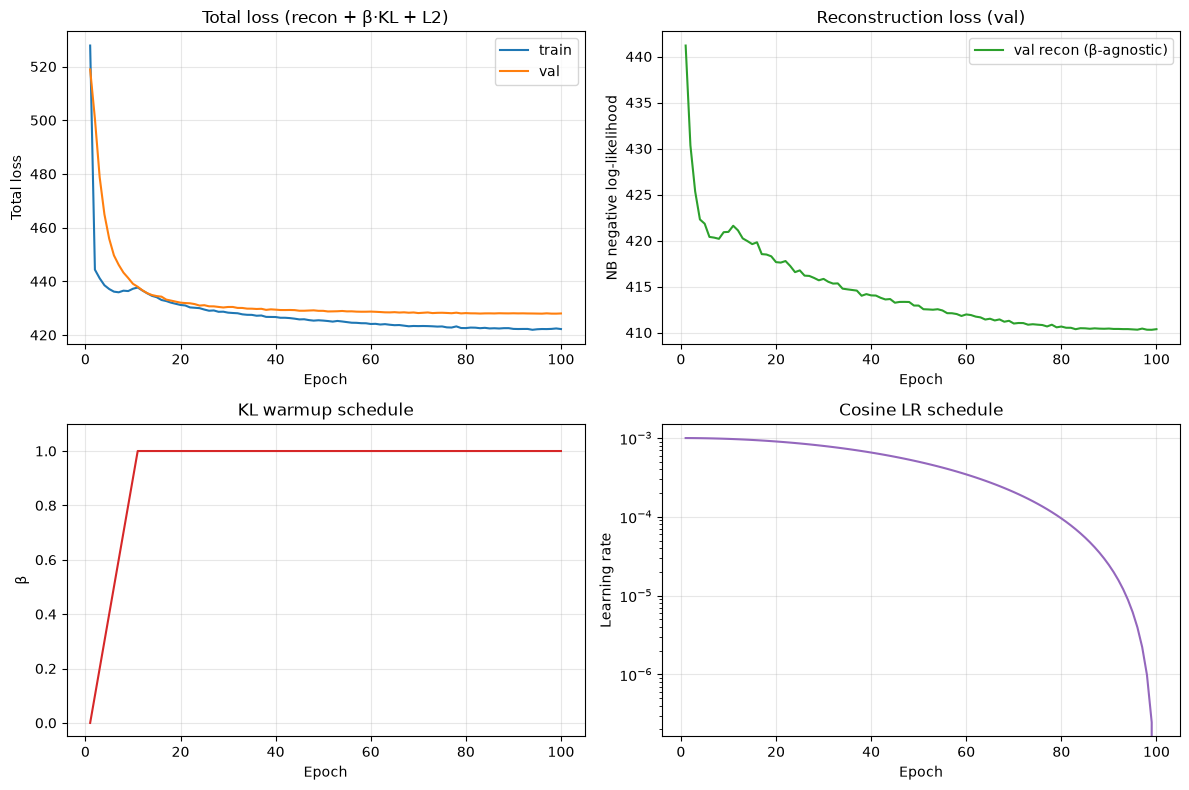

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

epochs_range = np.arange(1, len(history["train"]) + 1)

# Panel 1: total loss
ax = axes[0, 0]
ax.plot(epochs_range, history["train"], label="train")
ax.plot(epochs_range, history["val"], label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("Total loss")
ax.set_title("Total loss (recon + β·KL + L2)")
ax.legend()
ax.grid(alpha=0.3)

# Panel 2: reconstruction component only
ax = axes[0, 1]
ax.plot(epochs_range, history["recon"], label="val recon (β-agnostic)", color="C2")
ax.set_xlabel("Epoch")
ax.set_ylabel("NB negative log-likelihood")
ax.set_title("Reconstruction loss (val)")
ax.legend()
ax.grid(alpha=0.3)

# Panel 3: β schedule
ax = axes[1, 0]
ax.plot(epochs_range, history["beta"], color="C3")
ax.set_xlabel("Epoch")
ax.set_ylabel("β")
ax.set_title("KL warmup schedule")
ax.set_ylim(-0.05, 1.1)
ax.grid(alpha=0.3)

# Panel 4: learning rate
ax = axes[1, 1]
ax.plot(epochs_range, history["lr"], color="C4")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning rate")
ax.set_title("Cosine LR schedule")
ax.set_yscale("log")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Path("outputs").mkdir(exist_ok=True)
fig.savefig("outputs/training_history.png", dpi=100, bbox_inches="tight")
print("Saved plot to outputs/training_history.png")